<a href="https://colab.research.google.com/github/ayualfia/PBA-Amazon-SentimentAnalysis/blob/main/week3_amazonshopping_review_dataprepocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 - Data Preprocessing Review Aplikasi Amazon Shopping

Notebook ini digunakan untuk melakukan preprocessing terhadap dataset review aplikasi Amazon Shopping yang sebelumnya telah diperoleh dari proses scraping pada Week 2.

## Tujuan Notebook
1. Membaca dataset hasil scraping dari GitHub.
2. Membersihkan data kosong dan duplikat.
3. Melakukan tahapan preprocessing teks sesuai materi NLP Pipeline:
   - Tokenization
   - Lowering
   - Stopword Removal
   - Lemmatization
   - Stemming
   - Punctuation Removal
   - Expand Contractions
   - Spelling Correction
   - Rare Words Removal
   - Common Words Removal
4. Membandingkan teks sebelum dan sesudah preprocessing.
5. Menyimpan dataset hasil preprocessing.

## Sumber Data
- Aplikasi: Amazon Shopping
- File input: `data/amazon_reviews.csv`
- File output: `data/amazon_reviews_preprocessed.csv`

## Catatan
Kolom `content` digunakan sebagai teks utama yang akan diproses. Hasil akhir preprocessing disimpan dalam kolom `final_clean_text` dan `final_stemmed_text`.

In [1]:
# ============================================================
# INSTAL & IMPORT LIBRARY
# ============================================================
!pip install contractions nltk textblob wordcloud tqdm -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import contractions
import nltk

from collections import Counter
from tqdm.auto import tqdm
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer, PorterStemmer
from textblob import TextBlob

In [2]:
# ============================================================
# DOWNLOAD RESOURCE NLTK
# ============================================================

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
# ============================================================
# KONFIGURASI AWAL
# ============================================================

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Dataset hasil scraping Week 2 dari GitHub LFS
DATA_URL = "https://media.githubusercontent.com/media/ayualfia/PBA-Amazon-SentimentAnalysis/main/data/amazon_reviews.csv"

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

OUTPUT_PATH = os.path.join(DATA_DIR, "amazon_reviews_preprocessed.csv")

print("Input data:")
print(DATA_URL)

print("\nOutput data:")
print(OUTPUT_PATH)

Input data:
https://media.githubusercontent.com/media/ayualfia/PBA-Amazon-SentimentAnalysis/main/data/amazon_reviews.csv

Output data:
data/amazon_reviews_preprocessed.csv


In [4]:
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(DATA_URL, low_memory=False)

print("Dataset berhasil dimuat.")
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

df.head()

Dataset berhasil dimuat.
Jumlah baris: 334801
Jumlah kolom: 11


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,8013262e-eb1e-4063-a81f-bedec80a5db9,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"not compatible with Android tablets , Amazon y...",1,0,32.5.0.100,2026-03-09 18:57:26,NaN,NaN,32.5.0.100
1,ca281212-4ef4-4ffc-bc7b-777a8d76fdd1,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,You cannot complete a return on Android at all...,1,0,32.5.0.100,2026-03-09 18:51:08,NaN,NaN,32.5.0.100
2,f5cf5ff1-a4d3-4b17-834e-f2d9a6574929,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,app keeps crashing,2,0,32.5.0.100,2026-03-09 18:36:46,NaN,NaN,32.5.0.100
3,3cf55791-b25d-4463-8712-3f7a364c9718,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,I love this app for shopping but I just got a ...,3,0,32.5.0.100,2026-03-09 17:39:30,NaN,NaN,32.5.0.100
4,8395ddd2-82d2-4257-81f6-bcea60e600a7,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,GOOD 🥰🥰🥰 service,5,0,NaN,2026-03-09 17:32:49,NaN,NaN,NaN


In [5]:
# ============================================================
# INFORMASI DATASET
# ============================================================

print("Daftar kolom:")
print(df.columns.tolist())

print("\nInformasi dataset:")
df.info()

Daftar kolom:
['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334801 entries, 0 to 334800
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              334801 non-null  object
 1   userName              334801 non-null  object
 2   userImage             334801 non-null  object
 3   content               334801 non-null  object
 4   score                 334801 non-null  int64 
 5   thumbsUpCount         334801 non-null  int64 
 6   reviewCreatedVersion  269543 non-null  object
 7   at                    334801 non-null  object
 8   replyContent          55 non-null      object
 9   repliedAt             55 non-null      object
 10  appVersion            269543 non-null  object
dtypes: int64(2), object(9)
memory usage: 28

In [6]:
# ============================================================
# MEMILIH KOLOM UTAMA
# ============================================================

selected_columns = [
    "reviewId",
    "userName",
    "content",
    "score",
    "thumbsUpCount",
    "reviewCreatedVersion",
    "at"
]

available_columns = [col for col in selected_columns if col in df.columns]

df = df[available_columns].copy()

print("Kolom yang digunakan:")
print(df.columns.tolist())

df.head()

Kolom yang digunakan:
['reviewId', 'userName', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at']


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at
0,8013262e-eb1e-4063-a81f-bedec80a5db9,A Google user,"not compatible with Android tablets , Amazon y...",1,0,32.5.0.100,2026-03-09 18:57:26
1,ca281212-4ef4-4ffc-bc7b-777a8d76fdd1,A Google user,You cannot complete a return on Android at all...,1,0,32.5.0.100,2026-03-09 18:51:08
2,f5cf5ff1-a4d3-4b17-834e-f2d9a6574929,A Google user,app keeps crashing,2,0,32.5.0.100,2026-03-09 18:36:46
3,3cf55791-b25d-4463-8712-3f7a364c9718,A Google user,I love this app for shopping but I just got a ...,3,0,32.5.0.100,2026-03-09 17:39:30
4,8395ddd2-82d2-4257-81f6-bcea60e600a7,A Google user,GOOD 🥰🥰🥰 service,5,0,NaN,2026-03-09 17:32:49


In [7]:
# ============================================================
# KONVERSI KOLOM TANGGAL
# ============================================================

if "at" in df.columns:
    df["at"] = pd.to_datetime(df["at"], errors="coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334801 entries, 0 to 334800
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              334801 non-null  object        
 1   userName              334801 non-null  object        
 2   content               334801 non-null  object        
 3   score                 334801 non-null  int64         
 4   thumbsUpCount         334801 non-null  int64         
 5   reviewCreatedVersion  269543 non-null  object        
 6   at                    334801 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 17.9+ MB


In [8]:
# ============================================================
# CEK MISSING VALUE DAN DUPLIKAT
# ============================================================

print("Missing value:")
print(df.isnull().sum())

print("\nJumlah duplikat berdasarkan content:")
print(df["content"].duplicated().sum())

if "reviewId" in df.columns:
    print("\nJumlah duplikat berdasarkan reviewId:")
    print(df["reviewId"].duplicated().sum())

Missing value:
reviewId                    0
userName                    0
content                     0
score                       0
thumbsUpCount               0
reviewCreatedVersion    65258
at                          0
dtype: int64

Jumlah duplikat berdasarkan content:
39858

Jumlah duplikat berdasarkan reviewId:
0


In [9]:
# ============================================================
# HAPUS REVIEW KOSONG DAN DUPLIKAT
# ============================================================

before_cleaning = df.shape[0]

df_clean = df.copy()

# Menghapus review kosong
df_clean = df_clean.dropna(subset=["content"])
df_clean = df_clean[df_clean["content"].astype(str).str.strip() != ""]

# Menghapus duplikat
if "reviewId" in df_clean.columns:
    df_clean = df_clean.drop_duplicates(subset=["reviewId"])
else:
    df_clean = df_clean.drop_duplicates(subset=["content"])

after_cleaning = df_clean.shape[0]

print("Jumlah data sebelum cleaning:", before_cleaning)
print("Jumlah data setelah cleaning:", after_cleaning)
print("Jumlah data yang dihapus:", before_cleaning - after_cleaning)

Jumlah data sebelum cleaning: 334801
Jumlah data setelah cleaning: 334801
Jumlah data yang dihapus: 0


In [10]:
# ============================================================
# ORIGINAL TEXT
# ============================================================

df_clean["original_text"] = df_clean["content"].astype(str)

df_clean[["original_text"]].head()

,original_text
0,"not compatible with Android tablets , Amazon y..."
1,You cannot complete a return on Android at all...
2,app keeps crashing
3,I love this app for shopping but I just got a ...
4,GOOD 🥰🥰🥰 service


In [11]:
# ============================================================
# 1. EXPAND CONTRACTIONS
# Contoh: don't -> do not, I'm -> I am
# ============================================================

tqdm.pandas()

def expand_contractions_text(text):
    return contractions.fix(str(text))

df_clean["expanded_text"] = df_clean["original_text"].progress_apply(expand_contractions_text)

df_clean[["original_text", "expanded_text"]].head()

  0%|          | 0/334801 [00:00<?, ?it/s]

,original_text,expanded_text
0,"not compatible with Android tablets , Amazon y...","not compatible with Android tablets , Amazon y..."
1,You cannot complete a return on Android at all...,You cannot complete a return on Android at all...
2,app keeps crashing,app keeps crashing
3,I love this app for shopping but I just got a ...,I love this app for shopping but I just got a ...
4,GOOD 🥰🥰🥰 service,GOOD 🥰🥰🥰 service


In [12]:
# ============================================================
# 2. LOWERING / LOWERCASE
# ============================================================

df_clean["lowercase_text"] = df_clean["expanded_text"].str.lower()

df_clean[["expanded_text", "lowercase_text"]].head()

,expanded_text,lowercase_text
0,"not compatible with Android tablets , Amazon y...","not compatible with android tablets , amazon y..."
1,You cannot complete a return on Android at all...,you cannot complete a return on android at all...
2,app keeps crashing,app keeps crashing
3,I love this app for shopping but I just got a ...,i love this app for shopping but i just got a ...
4,GOOD 🥰🥰🥰 service,good 🥰🥰🥰 service


In [13]:
# ============================================================
# 3. PUNCTUATION REMOVAL
# Sekalian menghapus URL, HTML tag, angka, simbol, dan spasi berlebih
# ============================================================

def remove_punctuation(text):
    text = str(text)

    # Menghapus URL
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Menghapus HTML tag
    text = re.sub(r"<.*?>", " ", text)

    # Menghapus angka
    text = re.sub(r"\d+", " ", text)

    # Menghapus tanda baca dan simbol
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Menghapus spasi berlebih
    text = re.sub(r"\s+", " ", text).strip()

    return text

df_clean["punctuation_removed_text"] = df_clean["lowercase_text"].progress_apply(remove_punctuation)

df_clean[["lowercase_text", "punctuation_removed_text"]].head()

  0%|          | 0/334801 [00:00<?, ?it/s]

,lowercase_text,punctuation_removed_text
0,"not compatible with android tablets , amazon y...",not compatible with android tablets amazon you...
1,you cannot complete a return on android at all...,you cannot complete a return on android at all...
2,app keeps crashing,app keeps crashing
3,i love this app for shopping but i just got a ...,i love this app for shopping but i just got a ...
4,good 🥰🥰🥰 service,good service


In [14]:
# ============================================================
# 4. SPELLING CORRECTION
# ============================================================

def correct_spelling(text):
    return str(TextBlob(str(text)).correct())

# Karena dataset besar, default dibuat False
APPLY_SPELLING_CORRECTION = False

if APPLY_SPELLING_CORRECTION:
    df_clean["spelling_corrected_text"] = df_clean["punctuation_removed_text"].progress_apply(correct_spelling)
else:
    df_clean["spelling_corrected_text"] = df_clean["punctuation_removed_text"]

df_clean[["punctuation_removed_text", "spelling_corrected_text"]].head()

,punctuation_removed_text,spelling_corrected_text
0,not compatible with android tablets amazon you...,not compatible with android tablets amazon you...
1,you cannot complete a return on android at all...,you cannot complete a return on android at all...
2,app keeps crashing,app keeps crashing
3,i love this app for shopping but i just got a ...,i love this app for shopping but i just got a ...
4,good service,good service


In [15]:
# ============================================================
# 5. TOKENIZATION
# ============================================================

tokenizer = RegexpTokenizer(r"[a-zA-Z]+")

def tokenize_text(text):
    return tokenizer.tokenize(str(text))

df_clean["tokenized_text"] = df_clean["spelling_corrected_text"].progress_apply(tokenize_text)

df_clean[["spelling_corrected_text", "tokenized_text"]].head()

  0%|          | 0/334801 [00:00<?, ?it/s]

,spelling_corrected_text,tokenized_text
0,not compatible with android tablets amazon you...,"[not, compatible, with, android, tablets, amaz..."
1,you cannot complete a return on android at all...,"[you, cannot, complete, a, return, on, android..."
2,app keeps crashing,"[app, keeps, crashing]"
3,i love this app for shopping but i just got a ...,"[i, love, this, app, for, shopping, but, i, ju..."
4,good service,"[good, service]"


In [16]:
# ============================================================
# 6. STOPWORD REMOVAL
# ============================================================

english_stopwords = set(stopwords.words("english"))

def remove_stopwords(tokens):
    return [
        word for word in tokens
        if word not in english_stopwords and len(word) > 2
    ]

df_clean["stopword_removed_text"] = df_clean["tokenized_text"].progress_apply(remove_stopwords)

df_clean[["tokenized_text", "stopword_removed_text"]].head()

  0%|          | 0/334801 [00:00<?, ?it/s]

,tokenized_text,stopword_removed_text
0,"[not, compatible, with, android, tablets, amaz...","[compatible, android, tablets, amazon, lost, m..."
1,"[you, cannot, complete, a, return, on, android...","[cannot, complete, return, android, leaves, st..."
2,"[app, keeps, crashing]","[app, keeps, crashing]"
3,"[i, love, this, app, for, shopping, but, i, ju...","[love, app, shopping, got, new, pixel, tablet,..."
4,"[good, service]","[good, service]"


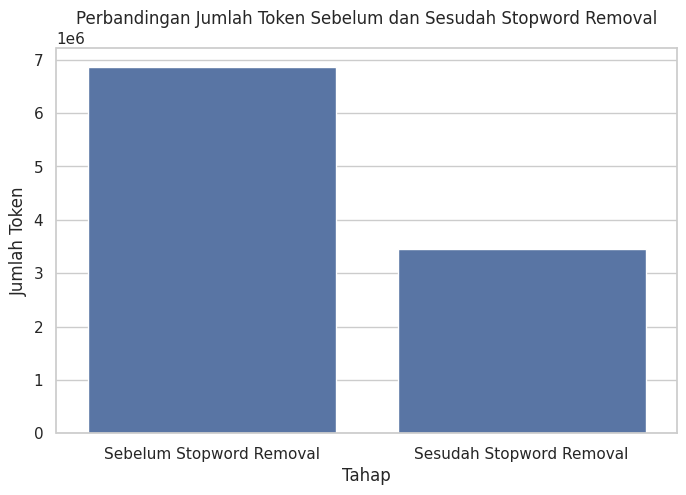

In [17]:
# ============================================================
# VISUALISASI TOKEN SEBELUM DAN SESUDAH STOPWORD REMOVAL
# ============================================================

total_token_before = df_clean["tokenized_text"].apply(len).sum()
total_token_after = df_clean["stopword_removed_text"].apply(len).sum()

token_comparison = pd.DataFrame({
    "Tahap": ["Sebelum Stopword Removal", "Sesudah Stopword Removal"],
    "Jumlah Token": [total_token_before, total_token_after]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=token_comparison, x="Tahap", y="Jumlah Token")
plt.title("Perbandingan Jumlah Token Sebelum dan Sesudah Stopword Removal")
plt.xlabel("Tahap")
plt.ylabel("Jumlah Token")
plt.show()

In [18]:
# ============================================================
# 7. LEMMATIZATION
# ============================================================

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df_clean["lemmatized_text"] = df_clean["stopword_removed_text"].progress_apply(lemmatize_tokens)

df_clean[["stopword_removed_text", "lemmatized_text"]].head()

  0%|          | 0/334801 [00:00<?, ?it/s]

,stopword_removed_text,lemmatized_text
0,"[compatible, android, tablets, amazon, lost, m...","[compatible, android, tablet, amazon, lost, mi..."
1,"[cannot, complete, return, android, leaves, st...","[cannot, complete, return, android, leaf, stuc..."
2,"[app, keeps, crashing]","[app, keep, crashing]"
3,"[love, app, shopping, got, new, pixel, tablet,...","[love, app, shopping, got, new, pixel, tablet,..."
4,"[good, service]","[good, service]"


In [19]:
# ============================================================
# 8. STEMMING
# ============================================================

stemmer = PorterStemmer()

def stem_tokens(tokens):
    return [stemmer.stem(word) for word in tokens]

df_clean["stemmed_text"] = df_clean["lemmatized_text"].progress_apply(stem_tokens)

df_clean[["lemmatized_text", "stemmed_text"]].head()

  0%|          | 0/334801 [00:00<?, ?it/s]

,lemmatized_text,stemmed_text
0,"[compatible, android, tablet, amazon, lost, mi...","[compat, android, tablet, amazon, lost, mind, ..."
1,"[cannot, complete, return, android, leaf, stuc...","[cannot, complet, return, android, leaf, stuck..."
2,"[app, keep, crashing]","[app, keep, crash]"
3,"[love, app, shopping, got, new, pixel, tablet,...","[love, app, shop, got, new, pixel, tablet, let..."
4,"[good, service]","[good, servic]"


In [20]:
# ============================================================
# GABUNGKAN TOKEN MENJADI TEKS
# ============================================================

df_clean["tokenized_text_joined"] = df_clean["tokenized_text"].apply(lambda x: " ".join(x))
df_clean["stopword_removed_text_joined"] = df_clean["stopword_removed_text"].apply(lambda x: " ".join(x))
df_clean["lemmatized_text_joined"] = df_clean["lemmatized_text"].apply(lambda x: " ".join(x))
df_clean["stemmed_text_joined"] = df_clean["stemmed_text"].apply(lambda x: " ".join(x))

df_clean[
    [
        "original_text",
        "tokenized_text_joined",
        "stopword_removed_text_joined",
        "lemmatized_text_joined",
        "stemmed_text_joined"
    ]
].head()

,original_text,tokenized_text_joined,stopword_removed_text_joined,lemmatized_text_joined,stemmed_text_joined
0,"not compatible with Android tablets , Amazon y...",not compatible with android tablets amazon you...,compatible android tablets amazon lost minds e...,compatible android tablet amazon lost mind eve...,compat android tablet amazon lost mind ever ma...
1,You cannot complete a return on Android at all...,you cannot complete a return on android at all...,cannot complete return android leaves stuck po...,cannot complete return android leaf stuck port...,cannot complet return android leaf stuck porti...
2,app keeps crashing,app keeps crashing,app keeps crashing,app keep crashing,app keep crash
3,I love this app for shopping but I just got a ...,i love this app for shopping but i just got a ...,love app shopping got new pixel tablet let ins...,love app shopping got new pixel tablet let ins...,love app shop got new pixel tablet let instal ...
4,GOOD 🥰🥰🥰 service,good service,good service,good service,good servic


In [21]:
# ============================================================
# 9. RARE WORDS REMOVAL
# ============================================================

all_words = []

for tokens in df_clean["lemmatized_text"]:
    all_words.extend(tokens)

word_freq = Counter(all_words)

# Kata yang muncul <= 2 kali dianggap rare words
RARE_WORD_THRESHOLD = 2

rare_words = {
    word for word, count in word_freq.items()
    if count <= RARE_WORD_THRESHOLD
}

print("Jumlah unique words:", len(word_freq))
print("Jumlah rare words:", len(rare_words))

Jumlah unique words: 49097
Jumlah rare words: 33353


In [22]:
# ============================================================
# MENGHAPUS RARE WORDS
# ============================================================

def remove_rare_words(tokens):
    return [word for word in tokens if word not in rare_words]

df_clean["rare_word_removed_text"] = df_clean["lemmatized_text"].progress_apply(remove_rare_words)
df_clean["rare_word_removed_text_joined"] = df_clean["rare_word_removed_text"].apply(lambda x: " ".join(x))

df_clean[["lemmatized_text_joined", "rare_word_removed_text_joined"]].head()

  0%|          | 0/334801 [00:00<?, ?it/s]

,lemmatized_text_joined,rare_word_removed_text_joined
0,compatible android tablet amazon lost mind eve...,compatible android tablet amazon lost mind eve...
1,cannot complete return android leaf stuck port...,cannot complete return android leaf stuck port...
2,app keep crashing,app keep crashing
3,love app shopping got new pixel tablet let ins...,love app shopping got new pixel tablet let ins...
4,good service,good service


In [23]:
# ============================================================
# 10. COMMON WORDS REMOVAL
# ============================================================

word_freq_after_rare = Counter()

for tokens in df_clean["rare_word_removed_text"]:
    word_freq_after_rare.update(tokens)

common_words_df = pd.DataFrame(
    word_freq_after_rare.most_common(30),
    columns=["word", "frequency"]
)

common_words_df

,word,frequency
0,app,117947
1,amazon,98733
2,love,40609
3,great,40204
4,time,35645
5,get,34300
6,order,33220
7,good,30966
8,item,30718
9,cannot,29854


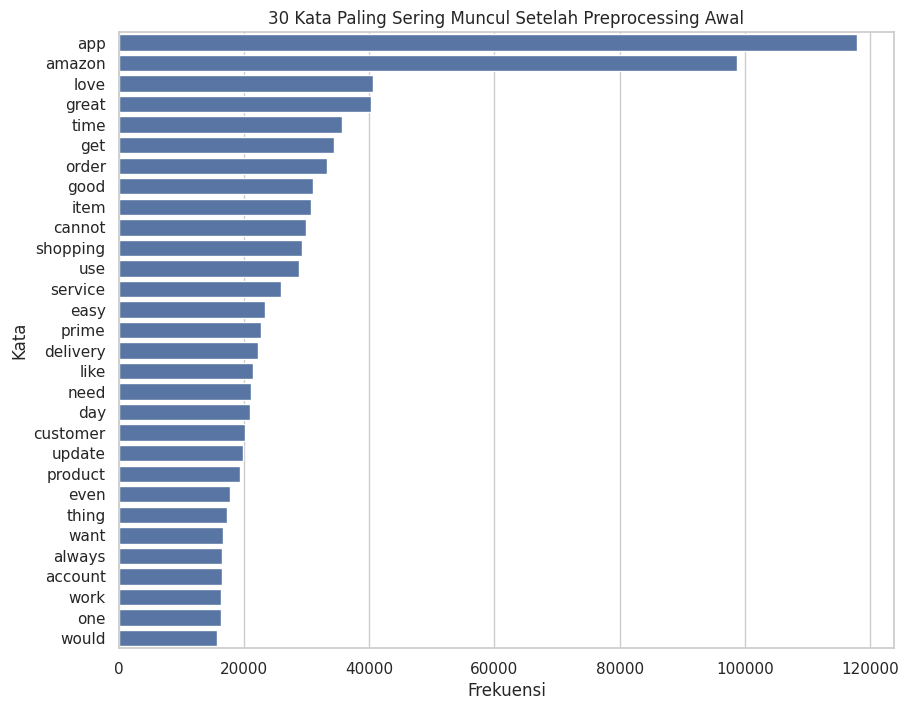

In [24]:
# ============================================================
# VISUALISASI COMMON WORDS
# ============================================================

plt.figure(figsize=(10, 8))
sns.barplot(data=common_words_df, x="frequency", y="word")
plt.title("30 Kata Paling Sering Muncul Setelah Preprocessing Awal")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.show()

In [25]:
# ============================================================
# MENGHAPUS COMMON WORDS DOMAIN
# ============================================================

common_domain_words = {
    "amazon",
    "app",
    "apps",
    "shopping",
    "store",
    "google",
    "play"
}

def remove_common_words(tokens):
    return [word for word in tokens if word not in common_domain_words]

df_clean["common_word_removed_text"] = df_clean["rare_word_removed_text"].progress_apply(remove_common_words)
df_clean["common_word_removed_text_joined"] = df_clean["common_word_removed_text"].apply(lambda x: " ".join(x))

df_clean[["rare_word_removed_text_joined", "common_word_removed_text_joined"]].head()

  0%|          | 0/334801 [00:00<?, ?it/s]

,rare_word_removed_text_joined,common_word_removed_text_joined
0,compatible android tablet amazon lost mind eve...,compatible android tablet lost mind ever made ...
1,cannot complete return android leaf stuck port...,cannot complete return android leaf stuck port...
2,app keep crashing,keep crashing
3,love app shopping got new pixel tablet let ins...,love got new pixel tablet let install personal...
4,good service,good service


In [26]:
# ============================================================
# FINAL CLEAN TEXT
# ============================================================

# Hasil akhir berbasis lemmatization
df_clean["final_clean_text"] = df_clean["common_word_removed_text_joined"]

# Hasil akhir berbasis stemming
df_clean["final_stemmed_text"] = df_clean["common_word_removed_text"].progress_apply(stem_tokens)
df_clean["final_stemmed_text"] = df_clean["final_stemmed_text"].apply(lambda x: " ".join(x))

df_clean[["content", "final_clean_text", "final_stemmed_text"]].head()

  0%|          | 0/334801 [00:00<?, ?it/s]

,content,final_clean_text,final_stemmed_text
0,"not compatible with Android tablets , Amazon y...",compatible android tablet lost mind ever made ...,compat android tablet lost mind ever made deci...
1,You cannot complete a return on Android at all...,cannot complete return android leaf stuck port...,cannot complet return android leaf stuck porti...
2,app keeps crashing,keep crashing,keep crash
3,I love this app for shopping but I just got a ...,love got new pixel tablet let install personal...,love got new pixel tablet let instal person th...
4,GOOD 🥰🥰🥰 service,good service,good servic


In [27]:
# ============================================================
# HAPUS FINAL CLEAN TEXT KOSONG
# ============================================================

before_final = df_clean.shape[0]

df_clean = df_clean[df_clean["final_clean_text"].astype(str).str.strip() != ""]

after_final = df_clean.shape[0]

print("Jumlah data sebelum hapus final kosong:", before_final)
print("Jumlah data setelah hapus final kosong:", after_final)
print("Jumlah data yang dihapus:", before_final - after_final)

Jumlah data sebelum hapus final kosong: 334801
Jumlah data setelah hapus final kosong: 332562
Jumlah data yang dihapus: 2239


In [28]:
# ============================================================
# PERBANDINGAN SEBELUM DAN SESUDAH PREPROCESSING
# ============================================================

comparison_df = df_clean[
    [
        "content",
        "expanded_text",
        "lowercase_text",
        "punctuation_removed_text",
        "tokenized_text_joined",
        "stopword_removed_text_joined",
        "lemmatized_text_joined",
        "stemmed_text_joined",
        "final_clean_text",
        "final_stemmed_text"
    ]
].head(10)

comparison_df

,content,expanded_text,lowercase_text,punctuation_removed_text,tokenized_text_joined,stopword_removed_text_joined,lemmatized_text_joined,stemmed_text_joined,final_clean_text,final_stemmed_text
0,"not compatible with Android tablets , Amazon y...","not compatible with Android tablets , Amazon y...","not compatible with android tablets , amazon y...",not compatible with android tablets amazon you...,not compatible with android tablets amazon you...,compatible android tablets amazon lost minds e...,compatible android tablet amazon lost mind eve...,compat android tablet amazon lost mind ever ma...,compatible android tablet lost mind ever made ...,compat android tablet lost mind ever made deci...
1,You cannot complete a return on Android at all...,You cannot complete a return on Android at all...,you cannot complete a return on android at all...,you cannot complete a return on android at all...,you cannot complete a return on android at all...,cannot complete return android leaves stuck po...,cannot complete return android leaf stuck port...,cannot complet return android leaf stuck porti...,cannot complete return android leaf stuck port...,cannot complet return android leaf stuck porti...
2,app keeps crashing,app keeps crashing,app keeps crashing,app keeps crashing,app keeps crashing,app keeps crashing,app keep crashing,app keep crash,keep crashing,keep crash
3,I love this app for shopping but I just got a ...,I love this app for shopping but I just got a ...,i love this app for shopping but i just got a ...,i love this app for shopping but i just got a ...,i love this app for shopping but i just got a ...,love app shopping got new pixel tablet let ins...,love app shopping got new pixel tablet let ins...,love app shop got new pixel tablet let instal ...,love got new pixel tablet let install personal...,love got new pixel tablet let instal person th...
4,GOOD 🥰🥰🥰 service,GOOD 🥰🥰🥰 service,good 🥰🥰🥰 service,good service,good service,good service,good service,good servic,good service,good servic
5,"shopping online with App, card, send to nunu, ...","shopping online with App, card, send to nunu, ...","shopping online with app, card, send to nunu, ...",shopping online with app card send to nunu woo...,shopping online with app card send to nunu woo...,shopping online app card send nunu woo amy boy...,shopping online app card send nunu woo amy boy...,shop onlin app card send nunu woo ami boy friend,online card send woo amy boy friend,onlin card send woo ami boy friend
6,they changed the return process of items. now ...,they changed the return process of items. now ...,they changed the return process of items. now ...,they changed the return process of items now s...,they changed the return process of items now s...,changed return process items comes ask dumb qu...,changed return process item come ask dumb ques...,chang return process item come ask dumb questi...,changed return process item come ask dumb ques...,chang return process item come ask dumb questi...
7,will not install on android 16 tablet! needs f...,will not install on android 16 tablet! needs f...,will not install on android 16 tablet! needs f...,will not install on android tablet needs fixin...,will not install on android tablet needs fixin...,install android tablet needs fixing use ali ex...,install android tablet need fixing use ali exp...,instal android tablet need fix use ali express,install android tablet need fixing use ali exp...,instal android tablet need fix use ali express
8,need to place a order,need to place a order,need to place a order,need to place a order,need to place a order,need place order,need place order,need place order,need place order,need place order
9,since I cannot use this app on my tablet I am ...,since I cannot use this app on my tablet I am ...,since i cannot use this app on my tablet i am ...,since i cannot use this app on my tablet i am ...,since i cannot use this app on my tablet i am ...,since cannot use app tablet cancelling amazon ...,sinc

In [29]:
# ============================================================
# WORD FREQUENCY SETELAH PREPROCESSING
# ============================================================

final_words = " ".join(df_clean["final_clean_text"].astype(str)).split()

final_word_freq = Counter(final_words)

final_word_freq_df = pd.DataFrame(
    final_word_freq.most_common(30),
    columns=["word", "frequency"]
)

final_word_freq_df

,word,frequency
0,love,40609
1,great,40204
2,time,35645
3,get,34300
4,order,33220
5,good,30966
6,item,30718
7,cannot,29854
8,use,28758
9,service,25892


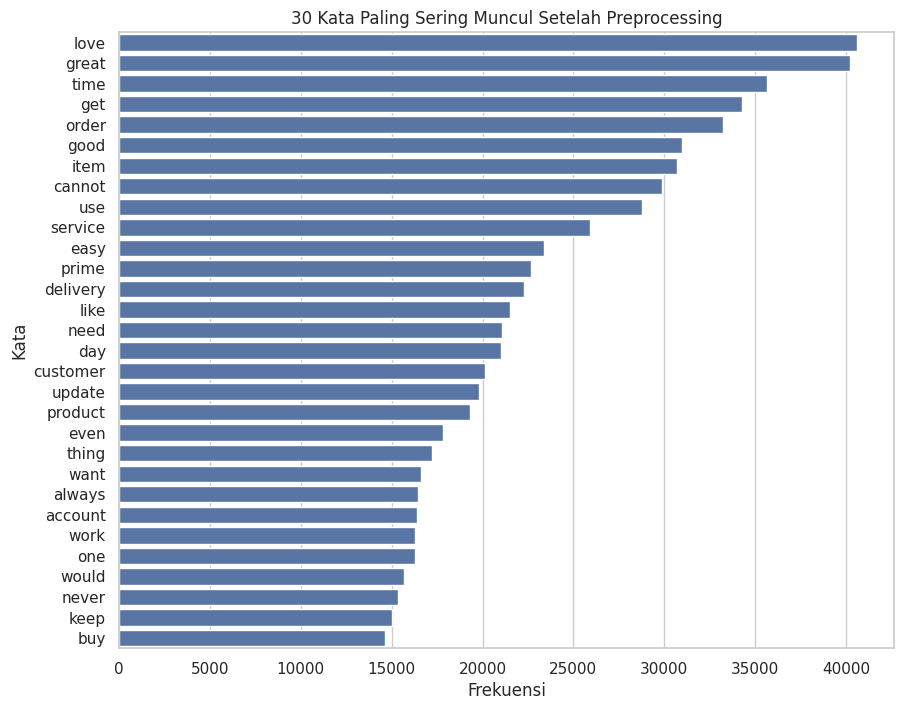

In [30]:
# ============================================================
# VISUALISASI WORD FREQUENCY SETELAH PREPROCESSING
# ============================================================

plt.figure(figsize=(10, 8))
sns.barplot(data=final_word_freq_df, x="frequency", y="word")
plt.title("30 Kata Paling Sering Muncul Setelah Preprocessing")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.show()

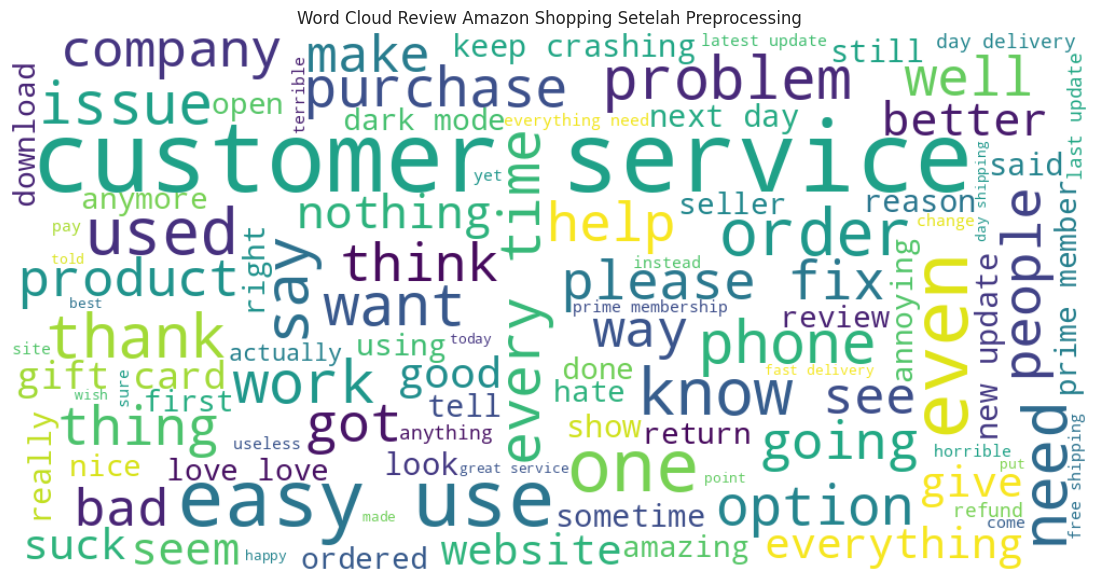

In [31]:
# ============================================================
# WORD CLOUD SETELAH PREPROCESSING
# ============================================================

text_data = " ".join(df_clean["final_clean_text"].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(text_data)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Review Amazon Shopping Setelah Preprocessing")
plt.show()

In [32]:
# ============================================================
# RINGKASAN HASIL PREPROCESSING
# ============================================================

summary = {
    "Jumlah data awal": df.shape[0],
    "Jumlah data setelah cleaning awal": after_cleaning,
    "Jumlah data akhir": df_clean.shape[0],
    "Total token sebelum stopword removal": total_token_before,
    "Total token setelah stopword removal": total_token_after,
    "Jumlah unique words": len(word_freq),
    "Jumlah rare words": len(rare_words)
}

summary_df = pd.DataFrame(
    list(summary.items()),
    columns=["Keterangan", "Nilai"]
)

summary_df

,Keterangan,Nilai
0,Jumlah data awal,334801
1,Jumlah data setelah cleaning awal,334801
2,Jumlah data akhir,332562
3,Total token sebelum stopword removal,6870537
4,Total token setelah stopword removal,3450976
5,Jumlah unique words,49097
6,Jumlah rare words,33353


In [33]:
# ============================================================
# DATASET FINAL YANG DISIMPAN
# ============================================================

final_columns = [
    "reviewId",
    "userName",
    "content",
    "score",
    "thumbsUpCount",
    "reviewCreatedVersion",
    "at",
    "final_clean_text",
    "final_stemmed_text"
]

available_final_columns = [col for col in final_columns if col in df_clean.columns]

df_final = df_clean[available_final_columns].copy()

print("Ukuran dataset final:")
print(df_final.shape)

df_final.head()

Ukuran dataset final:
(332562, 9)


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,final_clean_text,final_stemmed_text
0,8013262e-eb1e-4063-a81f-bedec80a5db9,A Google user,"not compatible with Android tablets , Amazon y...",1,0,32.5.0.100,2026-03-09 18:57:26,compatible android tablet lost mind ever made ...,compat android tablet lost mind ever made deci...
1,ca281212-4ef4-4ffc-bc7b-777a8d76fdd1,A Google user,You cannot complete a return on Android at all...,1,0,32.5.0.100,2026-03-09 18:51:08,cannot complete return android leaf stuck port...,cannot complet return android leaf stuck porti...
2,f5cf5ff1-a4d3-4b17-834e-f2d9a6574929,A Google user,app keeps crashing,2,0,32.5.0.100,2026-03-09 18:36:46,keep crashing,keep crash
3,3cf55791-b25d-4463-8712-3f7a364c9718,A Google user,I love this app for shopping but I just got a ...,3,0,32.5.0.100,2026-03-09 17:39:30,love got new pixel tablet let install personal...,love got new pixel tablet let instal person th...
4,8395ddd2-82d2-4257-81f6-bcea60e600a7,A Google user,GOOD 🥰🥰🥰 service,5,0,NaN,2026-03-09 17:32:49,good service,good servic


In [34]:
# ============================================================
# SIMPAN DATASET HASIL PREPROCESSING
# ============================================================

df_final.to_csv(OUTPUT_PATH, index=False, encoding="utf-8")

print("Dataset hasil preprocessing berhasil disimpan sebagai:")
print(OUTPUT_PATH)

Dataset hasil preprocessing berhasil disimpan sebagai:
data/amazon_reviews_preprocessed.csv


In [35]:
# ===================
# DOWNLOAD FILE CSV
# ===================

from google.colab import files

files.download(OUTPUT_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>